In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as smp
import statsmodels.formula.api as sm
from clickhouse_driver import Client
import joblib

## Домашка:

#### Описание
Вы продуктовый дата аналитик в авто классифайде. В компанию пришел новый дизайнер и предложил освежить дизайн карточки объявления которая не менялась за последние 6 лет. Ваша задача, проследить за метрикой конверсии из просмотра карточки объявления в контакт, чтобы она не упала.
Момент интервенции = с 2022-06-01

Изменения планируются ввести сначала в одной платформе (IOS), а затем на других, если гипотеза о том что конверсия не упадет более чем на -10% относительно, подтвердится.

#### Данные

таблица, dm_user_events

Контакт - Звонок/Сообщение по объявлению

#### Задачи

1) Выгрузите из таблицы user_dm_events аггрегировано по дням и платформам, метрику отноешения суммы контактов (SUM(cnt_display_phone + cnt_send_message))к просмотрам карточки объявления (SUM(cnt_view_advertisement))

За период 2022-01-01 - 2022-06-07.

На выходе должна получится аггрегированная таблица с колонками:
- event_date (дата аггрегации)
- platform (платформа совершения события)
- cnt_view_advertisement ( суммы просмотров карточки объявления)
- contact (сумма событий контактов)
- cr - отношение контактов к просмотрам на этот день в этой платформе

2) Постройте график динамики метрики в разрезе платформ и визуально посмотрите на динамику до и после изменения с 2022-06-01

3) оцените паралельны ли тренды с помощью Критерия Дики-Фуллера

4) Проанализируйте изменения с Diff-in-Diff с контрольной группой android, подтвердите или опровергните нулевую гипотезу:

    * Нулевая гипотеза подтверждается
    * Нулевая гипотеза опровергается
    
5) Укажите абсолютное изменение Diff-in-Diff    

6) Укажите относительное изменение Diff-in-Diff

8) Какой был p-value для этого изменения?

9) Оцените метрики ошибок для ковариаты как другой платформы android по данным за историю (до изменении), если для анализа понадобилось бы 7 дней. При минимальном кол-ве контрольной группы - 70% и кол-ве симуляции (без учета эффектов) - 30. А так же, при уровне достоверности 0.05 и оставляем без изменении random_state в функции

10) Укажите ошибку II рода для эффекта -5% округленным до сотых (0.XX)



In [ ]:
client = Client(host='clickhouse.lab.karpov.courses', port=9000, user='d-kazakov', password='4wDuJ3QcbjVP8L3dPZ9hNyBh', database='hardda')

In [ ]:
# подготовим функцию обращающуюся с запросом в clickhouse
def get_data(query):
    """
    Вытягивает данные из clickhouse в виде Dataframe

    query - запрос
    """
    result, columns = client.execute(query,with_column_types=True)
    return pd.DataFrame(result, columns=[tuple[0] for tuple in columns])

## 1 - Выгрузка
- 1.1. Средняя сумма контактов за день в Андроид
- 1.2. Средняя сумма просмотров за день в IOS

In [ ]:
# напишем запрос
query = """
SELECT
    event_date
    , platform
    , SUM(cnt_view_advertisement) AS cnt_view_advertisement
    , SUM(cnt_display_phone + cnt_send_message) AS contact

FROM
    user_dm_events
WHERE
    event_date BETWEEN '2022-01-01' AND '2022-06-07'
GROUP BY
    event_date
    , platform
"""

data = get_data(query)

In [ ]:
# посмотрим данные
data

,event_date,platform,cnt_view_advertisement,contact
0,2022-06-02,android,1475717,80184
1,2022-04-18,ios,633205,47158
2,2022-02-19,ios,507738,35602
3,2022-03-30,android,1775406,97654
4,2022-05-28,android,1415007,73005
...,...,...,...,...
249,2022-06-04,android,1370559,74468
250,2022-03-27,android,1992935,102864
251,2022-04-23,ios,582899,41781
252,2022-02-16,ios,538275,40988


In [ ]:
# 1.1
print('1.1. Средняя сумма контактов за день в Андроид' , round(data['contact'][data['platform'] == 'android'].mean(), 0))

1.1. Средняя сумма контактов за день в Андроид 94378.0


In [ ]:
#1.2
print('1.2. Средняя сумма просмотров за день в IOS'  , round(data['cnt_view_advertisement'][data['platform'] == 'ios'].mean(), 0))

1.2. Средняя сумма просмотров за день в IOS 536590.0


Выгружаем данные за период 2022-01-01 - 2022-06-07 по платформам, сумму событии по кол-во просмотров объявления, и сумму кол-ва просмотров телефона и отправки сообщении как контакт

Задаем изменения с 2022-06-01 как treatment и выделяем платформу ios как тестовую группу - intervention

In [ ]:
# немного преобразуем датасет и создадим метрику отношения
data['event_date'] = pd.to_datetime(data['event_date'])
data['cr'] = data['contact'] / data['cnt_view_advertisement']
data['intervention'] = np.where(data.event_date >= '2022-06-01', 1, 0) # указываем, где у нас было нововведение
data['treatment'] = np.where(data.platform == 'ios', 1, 0) # указываем treatment (ios) и control (android)
data

,event_date,platform,cnt_view_advertisement,contact,cr,intervention,treatment
0,2022-06-02,android,1475717,80184,0.054336,1,0
1,2022-04-18,ios,633205,47158,0.074475,0,1
2,2022-02-19,ios,507738,35602,0.070119,0,1
3,2022-03-30,android,1775406,97654,0.055004,0,0
4,2022-05-28,android,1415007,73005,0.051593,0,0
...,...,...,...,...,...,...,...
249,2022-06-04,android,1370559,74468,0.054334,1,0
250,2022-03-27,android,1992935,102864,0.051614,0,0
251,2022-04-23,ios,582899,41781,0.071678,0,1
252,2022-02-16,ios,538275,40988,0.076147,0,1


### построим график для наглядности

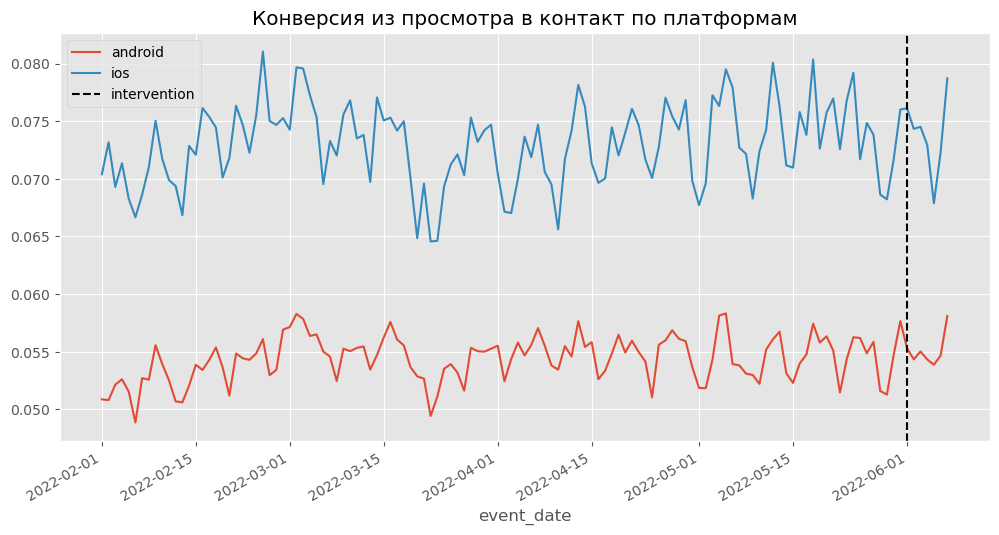

In [ ]:
plt.title('Конверсия из просмотра в контакт по платформам')
data.set_index('event_date').groupby(['platform']).cr.plot(figsize = (12, 6))
plt.axvline(x = '2022-06-01', color = 'black', linestyle = '--', label = 'intervention')
plt.legend();

Можем оценить динамику изменения метрики до и после intervention в разрезе платформ

# 3 - Оценим паралельность трендов
- 3.1. Укажите p-value тест Дики-Фуллера на pre периоде
- 3.2. Укажите абсолютную среднюю разницу между рядами на pre периоде
- 3.3. Стационарна ли разница во времени?

3.1. P-value тест Дики-Фуллера = 0.000705
3.2. Средняя разница cr между ios и android = 0.019
3.3. Разница между метрикой и ковариатой стационарна во времени? -> True


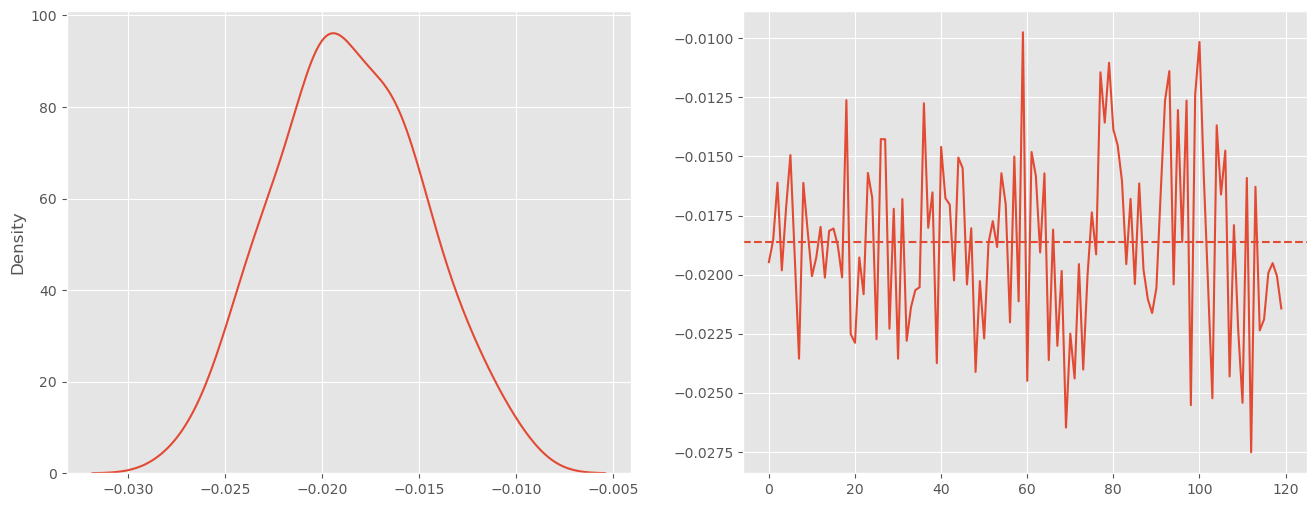

In [ ]:
ios_pre = np.array(data[(data['treatment'] == 1) & (data['event_date'] < '2022-06-01')].cr)
and_pre = np.array(data[(data['treatment'] == 0) & (data['event_date'] < '2022-06-01')].cr)
diff = ios_pre - and_pre
DF_pval = smp.tsa.stattools.adfuller(diff)[1]
print("3.1. P-value тест Дики-Фуллера = %f" % DF_pval)
print("3.2. Средняя разница cr между ios и android =", round(abs(diff.mean()),3))
print('3.3. Разница между метрикой и ковариатой стационарна во времени? ->', DF_pval < 0.05)
fig,axes = plt.subplots(1, 2, figsize=(16,6))
sns.kdeplot(ax=axes[0], data = diff)
axes[1].plot(diff)
axes[1].axhline(y = np.mean(diff),ls = '--')

## 4 - Анализ с помощью Diff-in-Diff
- 4.1. Отвергается ли нулевая гипотеза?
- 4.2. Укажите чему равна абсолютная diff-in-diff
- 4.3. Укажите p-value diff-in-diff анализа

In [ ]:
formula = 'cr ~ treatment + intervention + treatment * intervention'
model = sm.ols(formula = formula, data = data)
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                     cr   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     905.7
Date:                Sat, 21 Oct 2023   Prob (F-statistic):          6.06e-134
Time:                        19:41:23   Log-Likelihood:                 1130.4
No. Observations:                 254   AIC:                            -2253.
Df Residuals:                     250   BIC:                            -2239.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

In [ ]:
# 4.1
p_value = res.pvalues['treatment:intervention']
if p_value < 0.05:
    print('4.1. H0 отвергается')
else:
    print('4.1. H0 не отвергается')

4.1. H0 не отвергается


In [ ]:
# 4.2.
print('4.2. Diff-in-Diff =', round(res.params['treatment:intervention'], 5))

4.2. Diff-in-Diff = 0.00013


In [ ]:
# 4.3
print('4.3 p-value =', round(p_value, 3))

4.3 p-value = 0.932


## 5 - Оценка метрики ошибок
Проведите симуляцию ошибок 1 и 2 рода для эффектов [0.9, 0.95, 0.975, 1., 1.025, 1.05, 1.1]. Где 1 - нет эффекта
используйте следующие параметры для симуляции
- ковариата- 'android'
- n_days = 7,
- control_percent = 0.7
- n_sim = 100)

**Задания**
- 5.1. Укажите оценку ошибка II рода для эффекта -5%
- 5.2. Укажите оценку ошибки первого рода

In [ ]:
def causal_analysis(data, control_group, n_days = 14, control_percent = 0.7, sample_n = 50):
    '''
    data - наши исторические данные, на которых мы будем прогонять проверку критерия
    control_group - название переменной формирующих контрольную группу
    n_days - количество дней тестового периода. т.е. сколько мы предполагаем будет идти пост-период в днях.
                Задавать нужно так чтобы размер n_days не превышал 1-control_percent долю тестовых данных. Поэтому процент 1-control_percent нужно оставлять с запасом
    control_percent - доля истрических данных, которую мы резервируем для контрольного периода. Например не меньше 70%.
    sample_n - кол-во симмуляций. Сколько раз прогоняем на каждый проверяеммый эффект симмуляции (в коде по умолчанию 7 эффектов)

    '''
    n_days -= 1

    df_copy = data.copy()
    effects = [0.9, 0.95, 0.975, 1., 1.025, 1.05, 1.1] # Эффекты от снижения до увеличения. 1 - эффекта нет = АА вариант
    rel_effects = []

    dates = pd.DataFrame({'post_period_0': data.index}) # Даты

    # Самая первая дата контрольной группы
    initial = dates.values[0][0]
    # Тестовая группа, подбираем из неё sample_n рандомных дат в тестовом периоде, т.е. sample_n дат после control_percent дней.
    # мы как бы рандомно накидываем дни старта нововведения в тестовой зоне
    test = dates.iloc[int(len(dates)*(control_percent)):-n_days]\
                .sample(sample_n, random_state = 123, replace = True)\

    # Определяем пост и пре период в зависимости от полученных рандомных дат в тестовом периоде
    test['post_period_1'] = test.post_period_0 + pd.DateOffset(days = n_days)
    test['pre_period_0'] = initial
    test['pre_period_1'] = test.post_period_0 - pd.DateOffset(days = 1)

    test = test.astype(str)
    a = np.empty((sample_n, len(effects) + 2))

    def calculate_sse_mape_pval(d):
        sse = []
        mape = []
        p_vals = []
        for i in range(len(effects)):
            pre_period = [test.pre_period_0.values[d], test.pre_period_1.values[d]]
            post_period = [test.post_period_0.values[d], test.post_period_1.values[d]]

            # формируем датасеты для оценки эффектов. добавляем нужные эффекты
            df_copy = data.copy() # создаём другую переменную дубликата датафрейма чтобы каждый раз задавать новый эффект

            # указываем когда был intervention
            df_copy['intervention'] = 0
            df_copy.loc[post_period[0]:post_period[1], 'intervention'] = 1

            df_copy.loc[np.logical_and(
                        df_copy.index >= post_period[0], df_copy.index <= post_period[1]), 'y'] *= effects[i] # задаём эффект

            df_copy = pd.melt(df_copy.reset_index(), id_vars = ['index', 'intervention'], value_vars = ['y', control_group],
                 var_name = 'variable', value_name = 'value')
            df_copy['treatment'] = np.where(df_copy.variable == 'y', 1, 0)

            formula = 'value ~ treatment + intervention + treatment * intervention'
            model = sm.ols(formula = formula, data = df_copy)
            res = model.fit()

            b0 = res.params['Intercept']
            b1 = res.params['treatment']
            b2 = res.params['intervention']
            b3 = res.params['treatment:intervention']

            # Понимая как устроен Diff-in-Diff, можем с регрессии вычислить относительное изменение diff-in-diff
            rel_diff_in_diff = ((b0 + b1 + b2 + b3) / (b0 + b1)) / ((b0 + b2) / b0) - 1

            real_eff = effects[i] - 1
            to_sse = pow(rel_diff_in_diff - real_eff, 2) # считаем квадрат ошибок нашего нафденного diff-in-diff и реального
            to_mape = abs(rel_diff_in_diff - real_eff) * 100 # считаем квадрат ошибок нашего нафденного diff-in-diff и реального

            sse.append(to_sse)
            mape.append(to_mape)
            rel_effects.append(rel_diff_in_diff)
            p_vals.append(res.pvalues['treatment:intervention'])

        return (d, sum(sse), np.mean(mape), p_vals[effects.index(1)], p_vals[effects.index(1.025)],
               p_vals[effects.index(0.975)], p_vals[effects.index(1.05)], p_vals[effects.index(0.95)],
               p_vals[effects.index(1.1)], p_vals[effects.index(0.9)])

    results = joblib.Parallel(n_jobs=-1, verbose = len(test))(joblib.delayed(calculate_sse_mape_pval)(d) for d in range(len(test)))

    for result in results:
        d = result[0]
        a[d][0] = result[1]
        a[d][1] = result[2]
        a[d][2] = result[3]
        a[d][3] = result[4]
        a[d][4] = result[5]
        a[d][5] = result[6]
        a[d][6] = result[7]
        a[d][7] = result[8]
        a[d][8] = result[9]

    aa = pd.DataFrame(a, columns = ['sse', 'mape', 'p_val_1', 'p_val_1_025', 'p_val_0_975',
                                    'p_val_1_05', 'p_val_0_95', 'p_val_1_1', 'p_val_0_9'])
    final = test.reset_index().merge(aa.reset_index(), left_index = True, right_index = True)
    final.drop(columns = ['index_x', 'index_y'], inplace = True)
    final['control_group'] = control_group
    return final

Функция симуляции на исторических данных с синтетическими эффектами

In [ ]:
ts_data = data.query("event_date < '2022-06-01'")\
              .pivot_table(values = 'cr', index = 'event_date', columns = 'platform')
ts_data.rename(columns = {'ios': 'y'}, inplace = True)
ts_data.index.name = None
ts_data

platform,android,y
2022-02-01,0.050870,0.070403
2022-02-02,0.050799,0.073174
2022-02-03,0.052139,0.069300
2022-02-04,0.052607,0.071356
2022-02-05,0.051540,0.068276
...,...,...
2022-05-27,0.055862,0.073830
2022-05-28,0.051593,0.068635
2022-05-29,0.051281,0.068223
2022-05-30,0.054716,0.071668


Приводим данные в удобный вид

In [ ]:
%%time
n_sim = 100
res = pd.DataFrame()
caus = causal_analysis(ts_data, 'android', 7, 0.7, n_sim)
res = pd.concat([res, caus], axis = 0)
res

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:   

,post_period_0,post_period_1,pre_period_0,pre_period_1,sse,mape,p_val_1,p_val_1_025,p_val_0_975,p_val_1_05,p_val_0_95,p_val_1_1,p_val_0_9,control_group
0,2022-05-09,2022-05-15,2022-02-01,2022-05-08,8.346883e-04,1.089934,0.662468,0.112052,0.470014,0.006419,0.060393,8.779439e-07,0.000035,android
1,2022-04-28,2022-05-04,2022-02-01,2022-04-27,1.512149e-05,0.146702,0.979150,0.260363,0.237847,0.023516,0.019943,7.741925e-06,0.000005,android
2,2022-05-24,2022-05-30,2022-02-01,2022-05-23,2.730978e-04,0.623444,0.778898,0.387609,0.153962,0.045615,0.010429,2.614566e-05,0.000002,android
3,2022-04-28,2022-05-04,2022-02-01,2022-04-27,1.512149e-05,0.146702,0.979150,0.260363,0.237847,0.023516,0.019943,7.741925e-06,0.000005,android
4,2022-05-02,2022-05-08,2022-02-01,2022-05-01,3.478241e-03,2.224939,0.256353,0.020521,0.952802,0.000510,0.209383,1.249233e-08,0.000306,android
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-05-08,2022-05-14,2022-02-01,2022-05-07,8.699153e-04,1.112696,0.635216,0.103185,0.491793,0.005631,0.064898,6.903072e-07,0.000039,android
96,2022-05-14,2022-05-20,2022-02-01,2022-05-13,8.668228e-04,1.110717,0.533738,0.072871,0.577898,0.003203,0.083230,2.356894e-07,0.000055,android
97,2022-05-13,2022-05-19,2022-02-01,2022-05-12,8.661166e-04,1.110264,0.524572,0.070402,0.586218,0.003030,0.085046,2.126374e-07,0.000056,android
98,2022-04-27,2022-05-03,2022-02-01,2022-04-26,3.394787e-07,0.021981,0.992051,0.246302,0.253377,0.021650,0.022177,6.825756e-06,0.000006,android


In [ ]:
def to_res(data, to_group, n, alpha = 0.05):
    def p_val_count_alpha(p_val):
        return np.count_nonzero(p_val < alpha)

    def p_val_count_beta(p_val):
        return np.count_nonzero(p_val >= alpha)

    p_val_cols = data.filter(like = 'p_val').columns

    data['pre_period_diff'] = (pd.to_datetime(data.pre_period_1) - pd.to_datetime(data.pre_period_0))
    res = data.groupby([to_group]).agg({'sse': 'sum',
                                     'mape': 'mean',
                                     p_val_cols[0]: p_val_count_alpha,
                                     p_val_cols[1]: p_val_count_beta,
                                     p_val_cols[2]: p_val_count_beta,
                                     p_val_cols[3]: p_val_count_beta,
                                     p_val_cols[4]: p_val_count_beta,
                                     p_val_cols[5]: p_val_count_beta,
                                     p_val_cols[6]: p_val_count_beta,
                                     'pre_period_diff': 'mean'})

    res[p_val_cols[0]] = res[p_val_cols[0]] / n
    res[p_val_cols[1]] = res[p_val_cols[1]] / n
    res[p_val_cols[2]] = res[p_val_cols[2]] / n
    res[p_val_cols[3]] = res[p_val_cols[3]] / n
    res[p_val_cols[4]] = res[p_val_cols[4]] / n
    res[p_val_cols[5]] = res[p_val_cols[5]] / n
    res[p_val_cols[6]] = res[p_val_cols[6]] / n

    return res

In [ ]:
# аггрегируем все симуляции
res_conc = to_res(res, 'control_group', n_sim)
res_conc

,sse,mape,p_val_1,p_val_1_025,p_val_0_975,p_val_1_05,p_val_0_95,p_val_1_1,p_val_0_9,pre_period_diff
control_group,,,,,,,,,,
android,0.194715,1.443382,0.0,0.55,1.0,0.03,0.72,0.0,0.0,96 days 16:19:12


Можем посмотреть на метрику ошибок I рода которая здесь равна 0.00 и ошибку II рода для эффекта -5% которая равна 0.72

In [ ]:
# 5.1
print('5.1. Ошибка II рода для -5% =', res_conc.p_val_0_95.values[0].round(3))

5.1. Ошибка II рода для -5% = 0.72


In [ ]:
# 5.2
print('5.2. Ошибка I рода =', res_conc.p_val_1.values[0].round(3))

5.2. Ошибка I рода = 0.0
